In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("customer_features.csv")

In [3]:
features = [
    "total_spent",
    "total_orders",
    "average_order_value",
    "recency",
    "average_delivery_days",
    "average_review"
]

In [4]:
cluster_df = df[features].copy()

In [5]:
cluster_df = cluster_df.fillna(cluster_df.median())

In [6]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

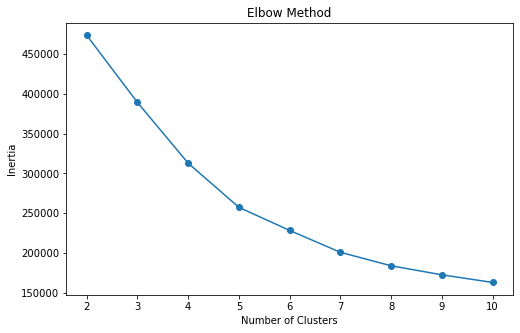

In [7]:
#Find Optimal K (Elbow Method)
inertia = []
K = range(2,11)
for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    model.fit(scaled_data)
    inertia.append(model.inertia_)
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

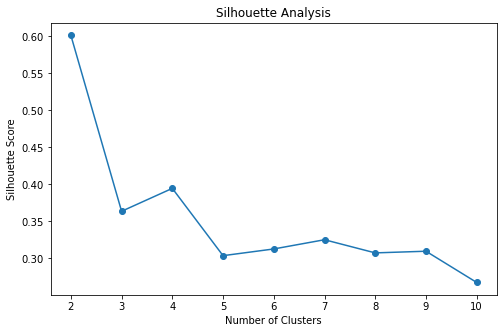

[0.6013976357424332, 0.3637162352859358, 0.39467471375546714, 0.3037457411220125, 0.3128104632988929, 0.32525933817425484, 0.30750030938044126, 0.30974634511160576, 0.26756495289662235]


In [8]:
scores = []
for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels = model.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    scores.append(score)
plt.figure(figsize=(8,5))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()
print(scores)

Note: The silhouette analysis was conducted to evaluate the optimal number of customer clusters for K-Means segmentation. Although the highest silhouette score (0.6014) was obtained with two clusters, this configuration resulted in overly broad customer groups that provided limited business value. A four-cluster solution, with a silhouette score of 0.3942, was selected because it offered a suitable balance between clustering quality and interpretability. Beyond four clusters, the silhouette scores showed only marginal changes, indicating that additional clusters did not significantly improve the separation of customer behaviors. Therefore, K = 4 was adopted for subsequent customer segmentation and profiling.

In [9]:
#Fit Final Model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)
df["Cluster"] = kmeans.fit_predict(scaled_data)

In [10]:
#Cluster Sizes
df["Cluster"].value_counts().sort_index()

Cluster
0    17376
1    73188
2     2569
3     2963
Name: count, dtype: int64

In [11]:
#Cluster Summary
summary = df.groupby("Cluster")[features].mean().round(2)
summary

,total_spent,total_orders,average_order_value,recency,average_delivery_days,average_review
Cluster,,,,,,
0,151.21,1.00,151.21,303.02,21.61,1.70
1,128.59,1.00,128.59,285.07,10.53,4.66
2,1155.32,1.01,1138.15,296.31,14.12,3.97
3,287.28,2.12,135.53,268.68,12.26,4.12


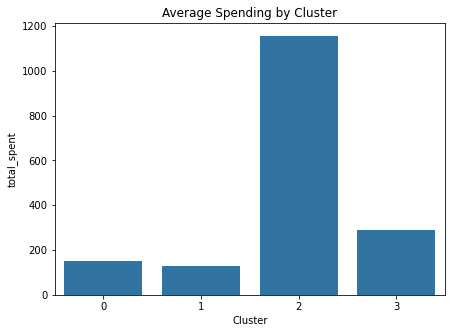

In [12]:
#Visualization
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x="Cluster",
    y="total_spent",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Spending by Cluster")
plt.show()

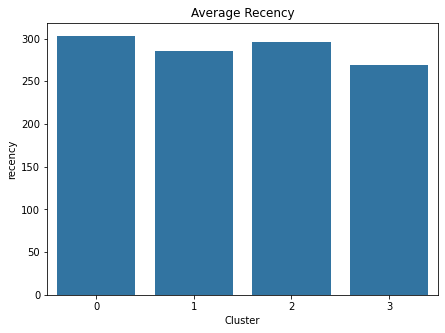

In [13]:
#Recency
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x="Cluster",
    y="recency",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Recency")
plt.show()

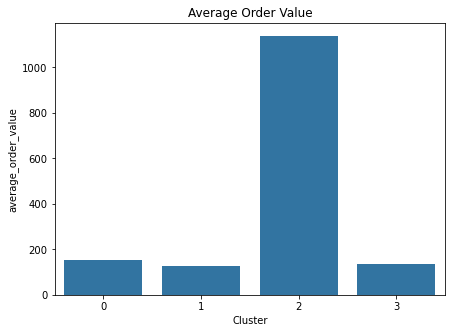

In [14]:
#Average Order Value
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x="Cluster",
    y="average_order_value",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Order Value")
plt.show()

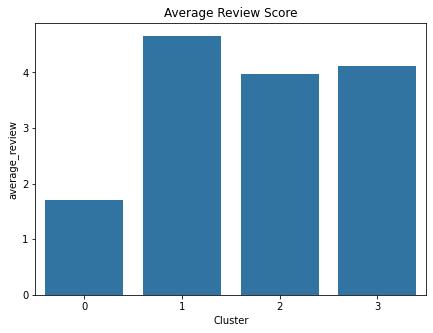

In [15]:
#Review Score
plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x="Cluster",
    y="average_review",
    estimator=np.mean,
    errorbar=None
)
plt.title("Average Review Score")
plt.show()

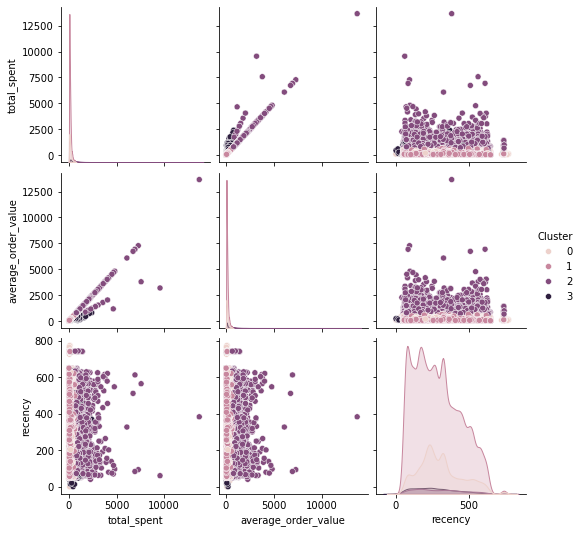

In [18]:
#Pairplot
sns.pairplot(
    df,
    vars=[
        "total_spent",
        "average_order_value",
        "recency"
    ],
    hue="Cluster"
)
plt.show()

In [19]:
#Cluster Profiles
profile = df.groupby("Cluster")[features].agg(["mean","median"])
profile

total_spent         total_orders        average_order_value           \
                mean  median         mean median                mean   median   
Cluster                                                                         
0         151.212369  114.57     1.000000    1.0          151.212369  114.570   
1         128.593995   98.88     1.000000    1.0          128.593995   98.880   
2        1155.318030  922.84     1.014402    1.0         1138.154799  919.460   
3         287.279642  222.23     2.116436    2.0          135.525497  106.845   

            recency        average_delivery_days        average_review         
               mean median                  mean median           mean median  
Cluster                                                                        
0        303.016229  277.0             21.608831   18.0       1.700675    1.0  
1        285.068058  268.0             10.531521    9.0       4.657022    5.0  
2        296.310237  279.0             14.121516   12.0       3.970600    5.0  
3        268.684104  248.0             12.258626   11.0       4.117744    4.5

###### Cluster 0 – Dissatisfied One-Time Customers

**Characteristics**

1) Lowest average spending (₹151.21)

2) One order per customer

3) Good delivery performance (21.6 days)

4) Highest average review score (1.70)

**Interpretation**

Customers are satisfied with their purchase experience but have not returned for additional purchases.
They represent an opportunity for repeat purchase campaigns.

##### Cluster 1 – Low-Spending One-Time Customers

**Characteristics**

1) Single purchase

2) Longest delivery time (10.5 days)

3) Lowest review score (4.66)

4) Moderate spending

**Interpretation**

Customers experienced poor service, most likely due to delivery delays, resulting in very low satisfaction.
These customers are unlikely to purchase again without intervention.

##### Cluster 2 – High-Value Customers

**Characteristics**

1) Highest average spending (₹1,138.15)

2) Highest average order value (₹1,155.31)

3) Mostly single purchases

4) Good review scores (3.98)

**Interpretation**

These customers generate substantial revenue through expensive purchases.
Although they purchase infrequently, each transaction contributes significantly to total sales.

##### Cluster 3 – Loyal Repeat Customers

**Characteristics**

1) Highest number of orders (2.12)

2) Moderate total spending (₹287.28)

3) Good review score (4.5)

4) Relatively recent purchases

5) Good delivery performance

**Interpretation**

These customers demonstrate repeat purchasing behaviour and consistent engagement.
They represent the retailer's most loyal customer base.

The K-Means clustering successfully identified four distinct customer segments based on spending, purchasing behaviour, delivery performance, and customer satisfaction. These segments provide actionable insights for developing targeted marketing campaigns, improving customer retention, optimizing delivery operations, and enhancing overall customer experience.

In [18]:
df.to_csv("customer_segmentation_kmeans.csv", index=False)